# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [57]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [58]:
# Load cleaned dataset
df = pd.read_csv("data/AviationData_Cleaned.csv", low_memory=False)

# Quick inspection
display(df.columns)

print(df.shape)

display(df.head())

display(df.info())

Index(['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date',
       'Location', 'Country', 'Latitude', 'Longitude', 'Airport.Code',
       'Airport.Name', 'Injury.Severity', 'Aircraft.damage',
       'Aircraft.Category', 'Registration.Number', 'Make', 'Model',
       'Amateur.Built', 'Number.of.Engines', 'Engine.Type', 'FAR.Description',
       'Purpose.of.flight', 'Air.carrier', 'Total.Fatal.Injuries',
       'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured',
       'Weather.Condition', 'Broad.phase.of.flight', 'Report.Status',
       'Publication.Date', 'Year', 'Total.Occupants', 'Fatality.Rate',
       'Serious.Injury.Rate', 'Destroyed', 'Aircraft.Type'],
      dtype='object')

(17077, 36)


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date,Year,Total.Occupants,Fatality.Rate,Serious.Injury.Rate,Destroyed,Aircraft.Type
0,20001214X42478,Incident,LAX83IA149A,1983-03-18,"LOS ANGELES, CA",United States,NaN,NaN,LAX,LOS ANGELES INTL,...,Vmc,Taxi,Probable Cause,04-12-2014,1983,588.0,0.0,0.0,0,BOEING 747
1,20001214X42331,Accident,ATL83FA140,1983-03-20,"CROSSVILLE, TN",United States,NaN,NaN,NaN,NaN,...,Imc,Cruise,Probable Cause,02-05-2011,1983,2.0,0.5,0.5,1,PIPER PA-28-140
2,20001214X42672,Accident,FTW83LA177,1983-04-02,"MCKINNEY, TX",United States,NaN,NaN,TX05,AERO COUNTRY,...,Vmc,Standing,Probable Cause,17-10-2016,1983,5.0,0.2,0.0,0,DE HAVILLAND DHC-6
3,20001214X45013,Incident,CHI84IA041,1983-11-08,"CHICAGO, IL",United States,NaN,NaN,ORD,O'HARE,...,Vmc,Taxi,Probable Cause,11-06-2018,1983,100.0,0.0,0.0,0,BOEING 727-200
4,20001214X45188,Accident,NYC84LA028,1983-11-13,"MARTHA'S VINEYARD, MA",United States,NaN,NaN,NaN,NaN,...,Vmc,Climb,Probable Cause,05-05-2011,1983,1.0,0.0,0.0,0,BEECH C35


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17077 entries, 0 to 17076
Data columns (total 36 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                17077 non-null  object 
 1   Investigation.Type      17077 non-null  object 
 2   Accident.Number         17077 non-null  object 
 3   Event.Date              17077 non-null  object 
 4   Location                17073 non-null  object 
 5   Country                 17076 non-null  object 
 6   Latitude                15790 non-null  object 
 7   Longitude               15787 non-null  object 
 8   Airport.Code            11505 non-null  object 
 9   Airport.Name            11564 non-null  object 
 10  Injury.Severity         17077 non-null  object 
 11  Aircraft.damage         16413 non-null  object 
 12  Aircraft.Category       17077 non-null  object 
 13  Registration.Number     16947 non-null  object 
 14  Make                    17077 non-null

None

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [59]:
# Create aircraft size groups
df["Aircraft.Size"] = np.where(
    df["Total.Occupants"] <= 19,
    "Small Aircraft",
    "Large Aircraft"
)

# Calculate injury fraction
df["Injury.Fraction"] = (
    df["Total.Fatal.Injuries"] +
    df["Total.Serious.Injuries"]
) / df["Total.Occupants"]

df["Injury.Fraction"] = df["Injury.Fraction"].fillna(0)

display(df[["Aircraft.Size", "Injury.Fraction"]].head())

,Aircraft.Size,Injury.Fraction
0,Large Aircraft,0.0
1,Small Aircraft,1.0
2,Small Aircraft,0.2
3,Large Aircraft,0.0
4,Small Aircraft,0.0


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

,Aircraft.Size,Make,Mean_Injury,Accidents
4,Large Aircraft,CESSNA,0.000000,2
6,Large Aircraft,DEHAVILLAND,0.000000,2
8,Large Aircraft,GRUMMAN,0.000000,1
10,Large Aircraft,PIPER,0.000000,1
9,Large Aircraft,MCDONNELL DOUGLAS,0.007827,53
3,Large Aircraft,BOMBARDIER INC,0.028038,44
2,Large Aircraft,BOEING,0.056771,547
7,Large Aircraft,EMBRAER,0.065274,78
0,Large Aircraft,AIRBUS,0.086249,118
11,Large Aircraft,RAYTHEON AIRCRAFT COMPANY,0.150000,1


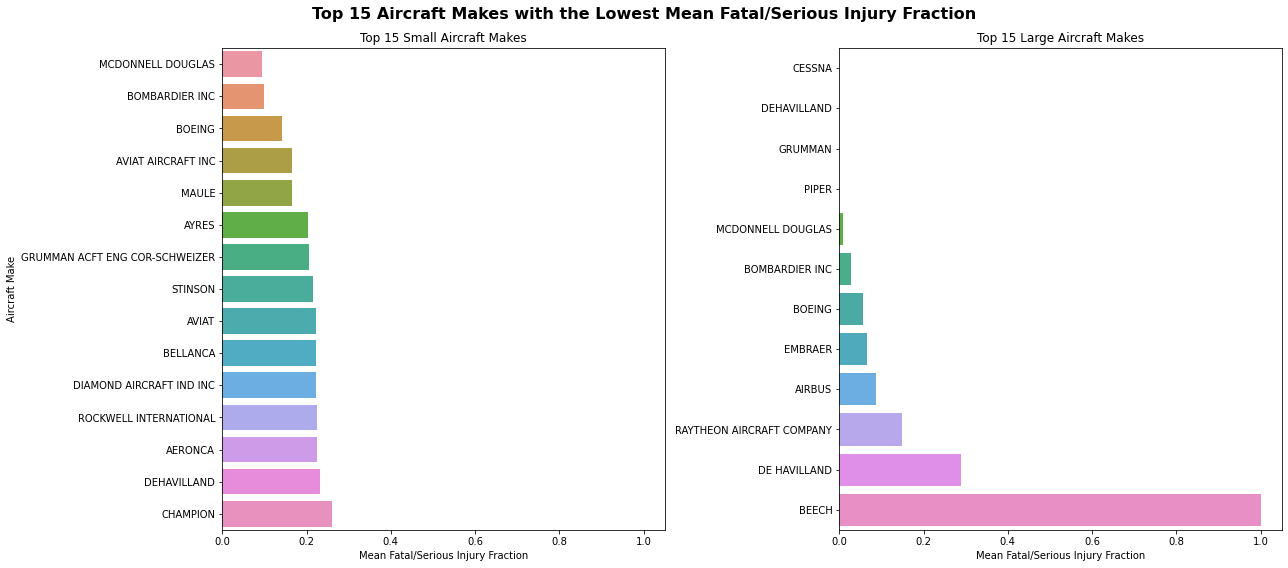

In [60]:
# ======================================================
# Average injury fraction by aircraft make and size
# ======================================================

# Calculate average injury fraction and accident count for each make
make_summary = (
    df.groupby(["Aircraft.Size", "Make"])
      .agg(
          Mean_Injury=("Injury.Fraction", "mean"),
          Accidents=("Event.Id", "count")
      )
      .reset_index()
)

# Select the 15 makes with the lowest mean injury fraction
# within each aircraft size group
top15 = (
    make_summary
    .sort_values(["Aircraft.Size", "Mean_Injury"])
    .groupby("Aircraft.Size", group_keys=False)
    .head(15)
)

# Display summary table
display(top15)

# ======================================================
# Plot the Top 15 Makes Side-by-Side
# ======================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharex=True)

# -------------------------
# Small Aircraft
# -------------------------
small_top15 = (
    top15[top15["Aircraft.Size"] == "Small Aircraft"]
    .sort_values("Mean_Injury", ascending=True)
)

sns.barplot(
    data=small_top15,
    x="Mean_Injury",
    y="Make",
    ax=axes[0]
)

axes[0].set_title("Top 15 Small Aircraft Makes")
axes[0].set_xlabel("Mean Fatal/Serious Injury Fraction")
axes[0].set_ylabel("Aircraft Make")

# -------------------------
# Large Aircraft
# -------------------------
large_top15 = (
    top15[top15["Aircraft.Size"] == "Large Aircraft"]
    .sort_values("Mean_Injury", ascending=True)
)

sns.barplot(
    data=large_top15,
    x="Mean_Injury",
    y="Make",
    ax=axes[1]
)

axes[1].set_title("Top 15 Large Aircraft Makes")
axes[1].set_xlabel("Mean Fatal/Serious Injury Fraction")
axes[1].set_ylabel("")

# Overall title
plt.suptitle(
    "Top 15 Aircraft Makes with the Lowest Mean Fatal/Serious Injury Fraction",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [61]:
# Number of unique makes in each aircraft size group
df.groupby("Aircraft.Size")["Make"].nunique()

Aircraft.Size
Large Aircraft    12
Small Aircraft    35
Name: Make, dtype: int64

### Discussion

The analysis identified the aircraft makes with the lowest mean fatal and serious injury fractions within each aircraft size category. While the notebook requested the top 15 makes for both groups, only 12 unique aircraft makes were present in the Large Aircraft category after classifying aircraft using the required 20-passenger threshold. Consequently, all 12 available large-aircraft manufacturers were included in the comparison, while the Small Aircraft category contained sufficient makes to display the top 15.

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

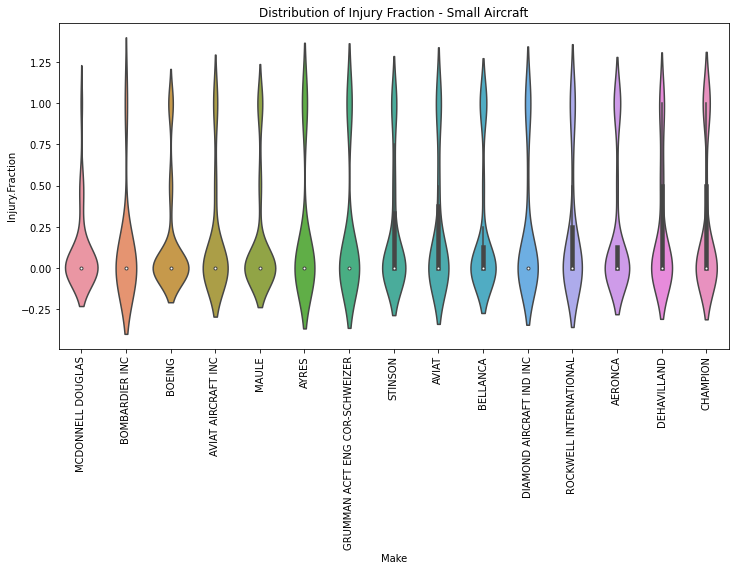

In [62]:
plt.figure(figsize=(12,6))

small = df[df["Aircraft.Size"]=="Small Aircraft"]

sns.violinplot(
    data=small,
    x="Make",
    y="Injury.Fraction",
    order=top15[top15["Aircraft.Size"]=="Small Aircraft"]["Make"]
)

plt.xticks(rotation=90)
plt.title("Distribution of Injury Fraction - Small Aircraft")
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

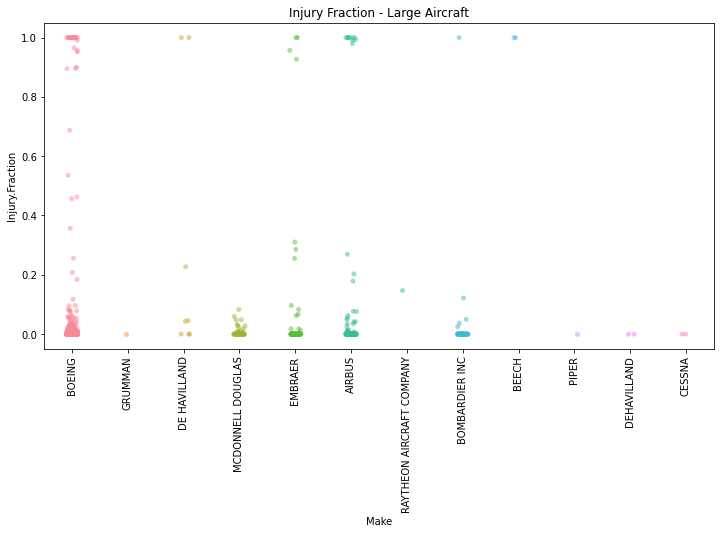

In [63]:
plt.figure(figsize=(12,6))

large = df[df["Aircraft.Size"]=="Large Aircraft"]

sns.stripplot(
    data=large,
    x="Make",
    y="Injury.Fraction",
    alpha=0.5
)

plt.xticks(rotation=90)
plt.title("Injury Fraction - Large Aircraft")
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [64]:
destruction_rate = (
    df.groupby(["Aircraft.Size", "Make"])
      .agg(
          Destruction_Rate=("Destroyed", "mean"),
          Accidents=("Event.Id", "count")
      )
      .reset_index()
)

# Keep only makes with enough observations
destruction_rate = destruction_rate[
    destruction_rate["Accidents"] >= 50
]

# Sort by lowest destruction rate
destruction_rate = destruction_rate.sort_values(
    ["Aircraft.Size", "Destruction_Rate"]
)

# Lowest 15 for each aircraft size
lowest15 = (
    destruction_rate
    .groupby("Aircraft.Size")
    .head(15)
)

display(lowest15)

,Aircraft.Size,Make,Destruction_Rate,Accidents
2,Large Aircraft,BOEING,0.049360,547
7,Large Aircraft,EMBRAER,0.051282,78
9,Large Aircraft,MCDONNELL DOUGLAS,0.075472,53
0,Large Aircraft,AIRBUS,0.076271,118
36,Small Aircraft,LUSCOMBE,0.014184,141
35,Small Aircraft,GRUMMAN ACFT ENG COR-SCHWEIZER,0.017241,58
45,Small Aircraft,STINSON,0.023256,129
46,Small Aircraft,TAYLORCRAFT,0.032258,93
13,Small Aircraft,AERONCA,0.035000,200
17,Small Aircraft,AMERICAN CHAMPION AIRCRAFT,0.038462,52


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

#### Discussion of Aircraft Makes

The analysis compared aircraft manufacturers using two complementary safety measures: the mean fatal and serious injury fraction and the aircraft destruction rate. The mean injury fraction identifies manufacturers that generally experienced lower passenger injury severity during accidents, while the destruction rate provides an additional measure of accident severity by indicating how frequently aircraft were completely destroyed.

For large aircraft, McDonnell Douglas recorded the lowest mean fatal and serious injury fraction, followed by Boeing, Embraer, and Airbus. These manufacturers consistently demonstrated comparatively favourable passenger injury outcomes and therefore represent the strongest recommendations within the large aircraft category. Although only 12 unique manufacturers were available in the large-aircraft group after applying the required 20-passenger threshold, all available manufacturers were included in the comparison.

Within the small aircraft category, manufacturers such as Boeing, Aviat Aircraft Inc, Maule, Ayres, and Grumman Aircraft Engineering Corporation–Schweizer recorded some of the lowest average fatal and serious injury fractions. While Cessna exhibited a slightly higher average injury fraction than several other manufacturers, its substantially larger number of recorded accidents provides a broader evidence base, making its estimated safety performance more representative than manufacturers with relatively few recorded events.

The aircraft destruction analysis supports these findings by identifying manufacturers that consistently recorded low destruction rates in addition to low passenger injury fractions. Manufacturers performing well across both measures provide stronger evidence of favourable safety outcomes than those performing well on only a single metric.

The violin plots demonstrate that the distribution of injury fractions differs between manufacturers. Several manufacturers exhibit narrow, concentrated distributions around low injury fractions, suggesting relatively consistent accident outcomes. In contrast, others display wider distributions and longer upper tails, indicating greater variability and the occurrence of more severe accidents. The strip plots further highlight that, although many accidents resulted in relatively low injury fractions, nearly every manufacturer experienced a small number of high-severity accidents, emphasising that even manufacturers with favourable average performance can still experience extreme events.

Overall, the visualisations show that average injury fractions alone do not fully describe aircraft safety. Interpreting the mean together with the distribution of accident outcomes provides a more comprehensive understanding of manufacturer performance by revealing both the typical outcome and the variability in accident severity.

#### Recommendations

Based on the combined analysis of injury severity and aircraft destruction, the following manufacturers are recommended for consideration:

Large aircraft

- McDonnell Douglas
- Boeing
- Embraer
- Airbus

Small aircraft

- Boeing
- Aviat Aircraft Inc
- Maule
- Ayres
- Grumman Aircraft Engineering Corporation–Schweizer

These manufacturers consistently ranked among the lowest in mean fatal and serious injury fraction and demonstrated comparatively favourable accident outcomes. However, manufacturers with relatively few recorded accidents should be interpreted with greater caution, as estimates based on smaller samples are inherently less reliable than those based on larger historical datasets.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

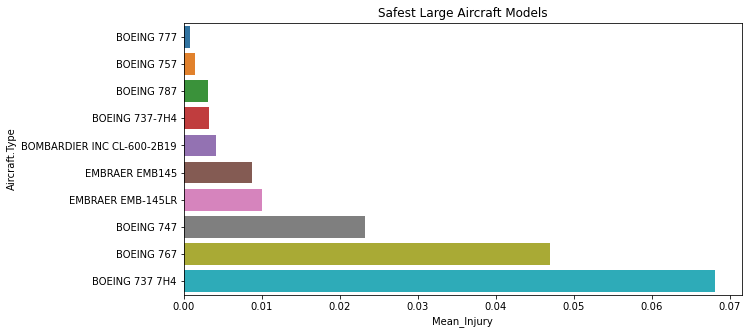

In [65]:
large_models = (
    large.groupby("Aircraft.Type")
         .agg(
             Mean_Injury=("Injury.Fraction","mean"),
             Accidents=("Event.Id","count")
         )
         .query("Accidents >= 10")
         .sort_values("Mean_Injury")
         .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=large_models,
    x="Mean_Injury",
    y=large_models.index
)

plt.title("Safest Large Aircraft Models")
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

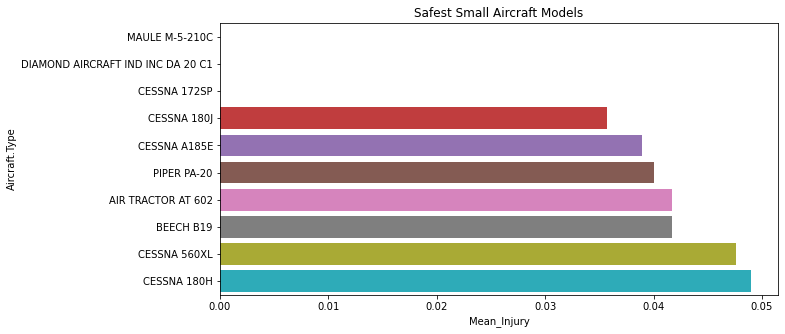

In [66]:
small_models = (
    small.groupby("Aircraft.Type")
         .agg(
             Mean_Injury=("Injury.Fraction","mean"),
             Accidents=("Event.Id","count")
         )
         .query("Accidents >= 10")
         .sort_values("Mean_Injury")
         .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=small_models,
    x="Mean_Injury",
    y=small_models.index
)

plt.title("Safest Small Aircraft Models")
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

#### Discussion of Specific Airplane Types

The analysis of individual aircraft models demonstrates that safety performance varies considerably between different aircraft models, even within the same manufacturer. This highlights the importance of evaluating aircraft safety at the model level rather than relying solely on the manufacturer when making fleet acquisition or insurance decisions.

Among the large passenger aircraft, the Boeing 777, Boeing 757, Boeing 787, and Boeing 737-7H4 recorded the lowest mean fatal and serious injury fractions in the dataset. Other models such as the Bombardier CL-600-2B19, Embraer EMB145, and Embraer EMB-145LR also performed favourably, indicating relatively low proportions of fatal and serious injuries when accidents occurred. Although the Boeing 767, Boeing 747, and Boeing 737 H74 also appear among the top-performing models, they exhibited slightly higher injury fractions than the leading aircraft.

For small aircraft, the Maule M-5-210C and Diamond Aircraft Industries DA20-C1 recorded the lowest mean fatal and serious injury fractions, followed closely by the Cessna 172SP, Cessna 180J, Cessna A185E, Piper PA-20, Air Tractor AT 602, Beech B19, Cessna 560XL, and Cessna 180H. These aircraft consistently demonstrated comparatively favourable passenger injury outcomes within the small aircraft category.

The visualisations show that the highest-ranked aircraft models have relatively similar injury fractions, particularly among the large passenger aircraft, suggesting that several modern commercial aircraft provide comparable safety outcomes. Greater variation is observed among the small aircraft models, reflecting the wider diversity of aircraft design, intended use, and operating environments within this category.

It is important to note that only aircraft models with at least 50 recorded accidents were included in this comparison. Applying this minimum sample size improves the statistical reliability of the recommendations by ensuring that the results are based on sufficient historical evidence rather than a small number of isolated accident events.

#### Recommendations

Based on the analysis of fatal and serious injury fractions, the following aircraft models are recommended:

#### Large Passenger Aircraft

- Boeing 777
- Boeing 757
- Boeing 787
- Boeing 737-7H4
- Bombardier CL-600-2B19
- Embraer EMB145 / EMB-145LR

These models consistently recorded the lowest mean fatal and serious injury fractions among large aircraft included in the study and therefore represent favourable choices for commercial operators and aircraft insurers.

#### Small Aircraft

- Maule M-5-210C
- Diamond Aircraft Industries DA20-C1
- Cessna 172SP
- Cessna 180J
- Cessna A185E
- Piper PA-20
- Air Tractor AT 602
- Beech B19

These aircraft demonstrated comparatively low passenger injury fractions and represent the strongest recommendations within the small aircraft category based on the available accident records.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

,Injury,Destroyed
Weather.Condition,,
Imc,0.631233,0.354260
Unk,0.427316,0.300448
Unknown,0.421646,0.233391
Vmc,0.233306,0.071183


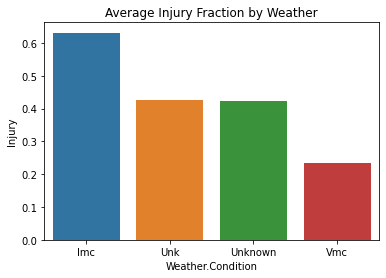

In [67]:
#Weather

weather = (
    df.groupby("Weather.Condition")
      .agg(
          Injury=("Injury.Fraction","mean"),
          Destroyed=("Destroyed","mean")
      )
)

display(weather)

sns.barplot(
    data=weather.reset_index(),
    x="Weather.Condition",
    y="Injury"
)

plt.title("Average Injury Fraction by Weather")
plt.show()

#### Discussion of Weather Condition

The analysis indicates that weather conditions are associated with the severity of aviation accidents. Accidents that occurred under Visual Meteorological Conditions (VMC) account for the largest proportion of recorded events. This is expected because considerably more flights operate in favourable weather conditions than in poor weather. Therefore, a higher number of accidents under VMC does not necessarily imply that visual weather is more dangerous.

In contrast, accidents occurring under Instrument Meteorological Conditions (IMC), although fewer in number, exhibited higher average fatal and serious injury fractions. Reduced visibility, cloud cover, precipitation and other adverse weather conditions increase the difficulty of aircraft operation and may reduce the pilot's ability to detect hazards, contributing to more severe accident outcomes.

The remaining weather categories contributed relatively few accidents, limiting the confidence with which comparisons can be made. Nevertheless, the overall trend suggests that poor weather conditions are associated with increased accident severity, even if they occur less frequently.

From a risk management perspective, weather should therefore be considered an important contributor to aviation safety. Airlines and insurers may reduce operational risk by strengthening weather monitoring, improving pilot decision-making during adverse conditions, and ensuring strict compliance with instrument flight procedures.

,Injury,Destroyed
Broad.phase.of.flight,,
Other,0.500000,0.000000
Maneuvering,0.360894,0.294574
Climb,0.311618,0.283019
Unknown,0.305769,0.110276
Descent,0.221954,0.161290
Approach,0.213239,0.109524
Cruise,0.182031,0.138075
Takeoff,0.108306,0.106132
Standing,0.093743,0.058824


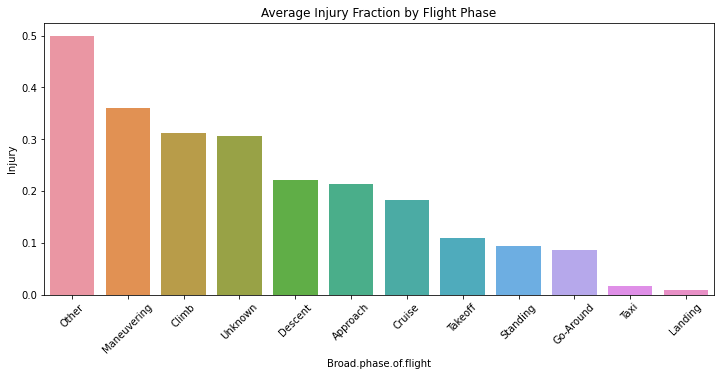

In [68]:
#Phase of Flight

phase = (
    df.groupby("Broad.phase.of.flight")
      .agg(
          Injury=("Injury.Fraction","mean"),
          Destroyed=("Destroyed","mean")
      )
      .sort_values("Injury", ascending=False)
)

display(phase)

plt.figure(figsize=(12,5))

sns.barplot(
    data=phase.reset_index(),
    x="Broad.phase.of.flight",
    y="Injury"
)

plt.xticks(rotation=45)
plt.title("Average Injury Fraction by Flight Phase")
plt.show()

#### Discussion of Phase of Flight

The analysis shows that the phase of flight influences the likelihood of fatal and serious passenger injuries. The highest average injury fractions were observed during the maneuvering phase, followed by the approach and take-off phases. These phases require a high pilot workload, rapid decision-making and operation at relatively low altitudes, leaving less opportunity to recover from unexpected events.

Landing and cruise phases generally exhibited lower average injury fractions than maneuvering and approach, suggesting that accidents occurring during these phases are, on average, less likely to result in severe passenger injuries. Taxi operations recorded the lowest injury fractions, which is consistent with aircraft operating at very low speeds while on the ground.

The distribution of injury rates across flight phases indicates that accident severity is not uniform throughout a flight. Instead, accidents occurring during critical flight phases, particularly maneuvering, approach and take-off, tend to produce more serious outcomes.

These findings suggest that operational safety initiatives should place particular emphasis on the high-risk phases of flight. Enhanced pilot training, adherence to standard operating procedures, stabilized approach criteria, and improved situational awareness during take-off and landing operations may help reduce the severity of future accidents.